# Best Practices for Training ANNs

# Challenges in Training ANNs

We have introduced standard MLPs, which are generally shallow networks, with just a few layers. What if you need to tackle a very complex problem, such as detecting hundreds of types of objects in high-resolution images? You may need to train a much deeper architecture, perhaps with 10 layers or much more, each containing hundreds of neurons, connected by hundreds of thousands of connections. This would not be an easy task.

1. **Vanishing gradient problem**. You would be faced with the tricky vanishing gradients problem (or the related exploding gradients problem) that affects deep neural networks and makes lower layers very hard to train. 

2. **Not enough training data**. You might not have enough training data for such a large network, or it might be too costly to label. 

3. **Training is too slow**. Training may be extremely slow. 

4. **Model has millions of parameters causing a severe risk of overfitting**. A model with millions of parameters would severely risk overfitting the training set, especially if there are not enough training instances, or they are too noisy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

import tensorflow as tf
from tensorflow import keras

In [2]:
fashion_mnist = keras.datasets.fashion_mnist

(X_train_full, t_train_full), (X_test, t_test) = fashion_mnist.load_data()

X_train_full.shape, t_train_full.shape, X_test.shape, t_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [3]:
# Training and Validation sets
# First 5,000 samples as validation and the remaining ones as training samples
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
t_valid, t_train = t_train_full[:5000], t_train_full[5000:]

X_test = X_test / 255.0

In [4]:
class_names = np.array(["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"])

---

# 1. The Vanishing/Exploding Gradient Problem

* Backpropagation works by backpropagating the error gradients
* Gradients becomes smaller and smaller as it progresses down to lower layers, this is known as the **vanishing gradient problem**

**Solutions:**
1. Make variance of the output of each layer equal to the variances of its inputs
2. Utilize non-saturating activation functions
3. Batch normalization

## 1.1. Glorot and He Initialization

[In their paper](http://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf), Xavier Glorot and Yoshua Bengio propose a way to significantly alleviate the vanishing gradient problem. For the signal to flow properly, the authors argue that we need **the variance of the outputs of each layer to be equal to the variance of its inputs**, and we also need the gradients to have equal variance before and after flowing through a layer in the reverse direction.

* It is actually not possible to guarantee both unless the layer has an equal number of inputs and neurons (these numbers are called the fan-in and fan-out of the layer).

But they proposed a good compromise that has proven to work very well in practice: the connection weights of each layer must be initialized randomly as a Gaussian distribution with mean 0 and variance equal to 1 over the average fanning. This is known as the **Xavier Initialization**. 

In this table, you can see two other initializations that have also been shown to work empirically:

| Initialization | Activation Functions | $\sigma^2$ (Normal)|
| --              | --                             | --              | 
|  Glorot (2000)  |  None, Tanh, Sigmoid, Softmax  | $1/\text{fan}_{\text{avg}}$   |
|  He (2015)  |  ReLU and its variants  | $2/\text{fan}_{\text{in}}$   |
|  LeCunn (1999)  |  SELU  | $1/\text{fan}_{\text{in}}$   |

By default, Keras uses **Glorot initialization with a uniform distribution**. 

When creating a layer, you can change this to He initialization by setting ```kernel_initializer="he_uniform"``` or ```kernel_initializer="he_normal"``` like this:

In [5]:
keras.layers.Dense(10,
                  activation='relu',
                  kernel_initializer='he_normal')

# weights are initialized with Gaussian with mean 0 and variance 2/10=1/5

<Dense name=dense, built=False>

If you want He initialization with a uniform distribution but based on $\text{fan}_{\text{avg}}$ than $\text{fan}_{\text{in}}$, you can use the ```VarianceScaling``` initializer like this:

In [6]:
he_avg_init = keras.initializers.VarianceScaling(scale=2., 
                                                 mode='fan_avg', 
                                                 distribution='uniform')

keras.layers.Dense(10, 
                   activation='sigmoid', 
                   kernel_initializer=he_avg_init)

<Dense name=dense_1, built=False>

## 1.2. Non-Saturing Activation Functions

One of the insights in the 2010 paper by Glorot and Bengio was that the vanishing gradients problems were in part due to a poor choice of activation function.

* In deep architectures, sigmoid activation functions tend to saturate.

Other activation functions behave much better, in particular the **ReLU activation function**, mostly because it does not saturate for positive values and also because it is quite fast to compute.

* Unfortunately, the ReLU activation function is not perfect. It suffers from a problem known as the dying neurons: during training, some neurons effectively die, meaning they stop outputting anything other than 0. When this happens, it just keeps outputting 0s, and gradient descent does not affect it anymore since the gradient of the ReLU function is 0 when its input is negative.

To solve this problem, you may want to use a variant of the ReLU function, such as the **leaky ReLU**.

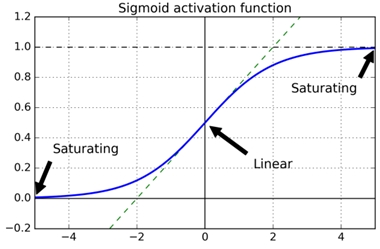

In [7]:
from IPython.display import Image
Image('figures/sigmoid.png',width=400)
# Source: "Hands-on machine learning with 
#scikit-learn and tensorflow" by Geron Aurelien

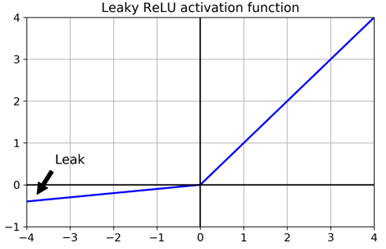

In [8]:
Image('figures/leaky_relu.png',width=400)
# Source: "Hands-on machine learning with 
#scikit-learn and tensorflow" by Geron Aurelien

* Current research has investigated different approaches to selecting the right slope for negative values. Namely, considering it a learnable parameter during training. This is known as the parametric leaky ReLU.

An alternative is to use the **Scaled Exponential Linear Unit, or SELU**. The output of each layer will tend to preserve mean 0 and standard deviation 1 during training, which solves the vanishing gradient problem.

The **Exponential Linear Unit (ELU)** is defined as:
\begin{align*}
\phi(x) = \begin{cases}x, & x> 0\\ \alpha(e^x-1), & x\leq 0\end{cases}
\end{align*}

typical values for $\alpha$ are $0.1\leq\alpha\leq 0.3$.

The **Scaled Exponential Linear Unit (SELU)** is defined as:
\begin{align*}
\phi(x) = \lambda\begin{cases}x, & x> 0\\ \alpha(e^x-1), & x\leq 0\end{cases}
\end{align*}

The [authors](https://arxiv.org/pdf/1706.02515.pdf) proposed to consider $\alpha\approx 1.6733$ and $\lambda \approx 1.0507$. When using this activation function in practice, one must use *Lecun Normal* for weight initialization, and if dropout wants to be applied, one should use *AlphaDropout*. More on this later in the code section.

In general we have the following relationship between the different activation function options:

> #### SELU > ELU > Leaky ReLU (and its variants) > ReLU > tanh > sigmoid

To use the leaky ReLU activation function, create a model just after the layer you want to apply it to: 

In [9]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer='he_normal'),
    keras.layers.LeakyReLU(alpha=0.2),
    keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dense(10, activation='softmax')
])

C:\Users\aramirezsalgado\AppData\Local\anaconda3\envs\ramirez_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\aramirezsalgado\AppData\Local\anaconda3\envs\ramirez_env\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


For SELU activation, set ```activation="selu"``` and ```kernel_initializer="lecun_normal"``` when creating a layer: 

In [10]:
layer = keras.layers.Dense(10, activation='selu', 
                           kernel_initializer='lecun_normal')

layer

<Dense name=dense_5, built=False>

## 1.3. Batch Normalization

The other popular approach for alleviating the vanishing gradient problem is to use **batch normalization**, first published in 2015.

* The technique consists of adding an operation in the model just before or after the activation function of each hidden layer, simply **zero-centering and normalizing each input then scaling and shifting the result** using two new learnable parameter vectors per layer: one for scaling, the other for shifting.

In other words, this operation lets the model learn the optimal scale and mean of each of the layer's inputs. 

In many cases, if you add a batch normalization layer as the very first layer of your neural network, you do not need to standardize your training set: the batch normalization layer will do it for you. Well, approximately, since it only looks at one batch at a time, and it can also rescale and shift each input feature.

Just add a ```BatchNormalization``` layer before or after each hidden layer's activation function, and optionally add a batch normalization layer as well as the first layer in your model:

In [11]:
model = keras.models.Sequential([ 
    keras.layers.Flatten(input_shape=[28, 28]), 
    keras.layers.BatchNormalization(), 
    keras.layers.Dense(300, activation='elu', kernel_initializer='he_normal'), 
    keras.layers.BatchNormalization(), 
    keras.layers.Dense(100, activation='elu', kernel_initializer='he_normal'), 
    keras.layers.BatchNormalization(), 
    keras.layers.Dense(10, activation='softmax') 
])

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 784)                 │           3,136 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 300)                 │           1,200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 100)                 │             400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 271,346 (1.04 MB)

 Trainable params: 268,978 (1.03 MB)

 Non-trainable params: 2,368 (9.25 KB)

The authors of the Batch Normalization (BN) paper argued in favor of adding the BN layers before the activation functions, rather than after (as we just did). There is some debate about this, as which is preferable seems to depend on the task - you can experiment with this too to see which option works best on your dataset. 

To add the BN layers before the activation functions, you must remove the activation function from the hidden layers and add them as separate layers after the BN layers. 

Moreover, since a Batch Normalization layer includes one offset parameter per input, you can remove the bias term from the previous layer (just pass use_bias=False when creating it):

In [13]:
model = keras.models.Sequential([ 
    keras.layers.Flatten(input_shape=[28, 28]), 
    keras.layers.BatchNormalization(), 
    keras.layers.Dense(300, kernel_initializer='he_normal', use_bias=False), 
    keras.layers.BatchNormalization(), 
    keras.layers.Activation('elu'), 
    keras.layers.Dense(100, kernel_initializer='he_normal', use_bias=False), 
    keras.layers.BatchNormalization(), 
    keras.layers.Activation('elu'), 
    keras.layers.Dense(10, activation='softmax') 
])

In [14]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 784)                 │           3,136 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 300)                 │         235,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 300)                 │           1,200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 100)                 │          30,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 100)                 │             400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 270,946 (1.03 MB)

 Trainable params: 268,578 (1.02 MB)

 Non-trainable params: 2,368 (9.25 KB)

## 1.4. Gradient Clipping

Another popular technique to mitigate the exploding gradients problem is to clip the gradients during backpropagation so that they never exceed some threshold. This is called **Gradient Clipping**. 

This technique is most often used in recurrent neural networks (RNNs), as Batch Normalization is tricky to use in RNNs. For other types of networks, BN is usually sufficient. In ```Keras```, implementing Gradient Clipping is just a matter of setting the ```clipvalue``` or ```clipnorm``` argument when creating an optimizer, like this:

In [15]:
optimizer = keras.optimizers.SGD(clipvalue=1.0, learning_rate=1.5) 

model.compile(loss='sparse_categorical_crossentropy', 
              optimizer=optimizer)

This optimizer will clip every component of the gradient vector to a value between $-1.0$ and $1.0$.

In [16]:
history = model.fit(X_train, t_train, epochs=5, batch_size=32,
                    validation_data=(X_valid, t_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.7531 - val_loss: 0.4266
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.4516 - val_loss: 0.3873
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.4123 - val_loss: 0.3888
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.3697 - val_loss: 0.3649
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.3588 - val_loss: 0.3639


# Saving and Restoring a Model

When using the Sequential API or the Functional API, saving a trained Keras model is as simple as it gets:

In [17]:
model.save('my_keras_model.h5')

Keras will use the HDF5 format to save both the model's architecture (including every layer's hyperparameters) and the values of all the model parameters for every layer (e.g., connection weights and biases). It also saves the optimizer (including its hyperparameters and any state it may have).

Loading the model is just as easy:

In [18]:
model = keras.models.load_model('my_keras_model.h5')

---

# 2. Transfer Learning

It is generally not a good idea to train a very large deep neural network architecture from scratch. Specially if you have limited computational resources and/or a small training dataset.

Instead, you should always try to find an **existing neural network that accomplishes a similar task** to the one you are trying to tackle, then just **reuse the lower layers of this network**: this is called **transfer learning**. It will not only speed up training considerably but will also require much less training data. 

* For example, suppose that you have access to a Deep Neural Network (DNN) that was trained to classify pictures into 100 different categories, including animals, plants, vehicles, and everyday objects. You now want to train a DNN to classify specific types of vehicles. These tasks are very similar, even partly overlapping, so you should try to reuse parts of the first network.

The **output layer of the original model should usually be replaced since it is most likely not useful at all for the new task**, and it may not even have the right number of outputs for the new task. 

Similarly, the upper hidden layers of the original model are less likely to be as useful as the lower layers, since the high-level features that are most useful for the new task may differ significantly from the ones that were most useful for the original task. Try freezing all the reused layers first, then train your model and see how it performs. Then try unfreezing one or two of the top hidden layers to let backpropagation tweak them and see if performance improves. 

* The more training data you have, the more layers you can unfreeze. 

It is also useful to reduce the learning rate when you unfreeze reused layers: this will avoid wrecking their fine-tuned weights.

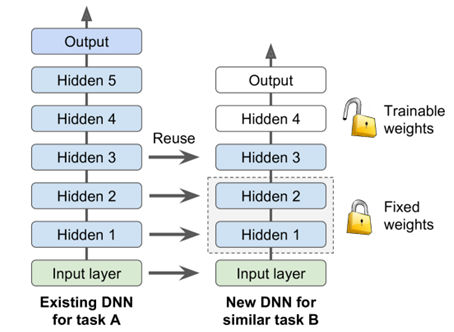

In [19]:
Image('figures/transfer_learning.png',width=400)
# Source: "Hands-on machine learning with scikit-learn and tensorflow" by Geron Aurelien

Let's demonstrate with the [flower species dataset](https://ufl.instructure.com/courses/524176/files/folder/flower_species_classification)

In [22]:
X_train_full = np.load('datasets/flower_species_classification/data_train.npy').T/255.0
t_train_full = np.load('datasets/flower_species_classification/labels_train.npy')

X_train_full.shape, t_train_full.shape

((1658, 270000), (1658,))

In [23]:
from sklearn.model_selection import train_test_split

# Training and Test sets
X_training, X_test, t_training, t_test = train_test_split(X_train_full, 
                                                  t_train_full, 
                                                  shuffle=True,
                                                  stratify=t_train_full,
                                                  test_size=0.15)
# Train and validation sets
X_train, X_val, t_train, t_val = train_test_split(X_training, 
                                                  t_training, 
                                                  shuffle=True,
                                                  stratify=t_training,
                                                  test_size=0.2)

X_training.shape, t_training.shape, X_train.shape, t_train.shape, X_val.shape, t_val.shape

((1409, 270000), (1409,), (1127, 270000), (1127,), (282, 270000), (282,))

In [24]:
class_names = ['Roses', 'Magnolias', 'Lilies', 'Sunflowers', 'Orchids', 'Marigold', 
               'Hibiscus', 'Firebush', 'Pentas', 'Bougainvillea']

In [25]:
X_train_rs = tf.constant(X_train.reshape((X_train.shape[0],300,300,3)), 
                         dtype=tf.float32)

X_train_rs.shape

TensorShape([1127, 300, 300, 3])

In [26]:
X_val_rs = tf.constant(X_val.reshape((X_val.shape[0],300,300,3)), 
                       dtype=tf.float32)

X_val_rs.shape

TensorShape([282, 300, 300, 3])

In [27]:
X_test_rs = tf.constant(X_test.reshape((X_test.shape[0],300,300,3)), 
                        dtype=tf.float32)

X_test_rs.shape

TensorShape([249, 300, 300, 3])

With this, we can now build TensorFlow models on this data:

In [28]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[300,300,3]),
    keras.layers.Dense(300, activation='relu'),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

C:\Users\aramirezsalgado\AppData\Local\anaconda3\envs\ramirez_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [29]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
             optimizer=tf.keras.optimizers.Nadam(),
             metrics=['accuracy'])

In [30]:
model.fit(X_train_rs, t_train, epochs=5, batch_size=32,
          validation_data=(X_val_rs, t_val),
         callbacks=[keras.callbacks.EarlyStopping(patience=30)])

Epoch 1/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 627ms/step - accuracy: 0.1269 - loss: 105.2285 - val_accuracy: 0.2695 - val_loss: 19.4160
Epoch 2/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 607ms/step - accuracy: 0.3442 - loss: 10.8494 - val_accuracy: 0.3369 - val_loss: 5.7614
Epoch 3/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 605ms/step - accuracy: 0.5225 - loss: 3.4736 - val_accuracy: 0.4184 - val_loss: 5.0980
Epoch 4/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 611ms/step - accuracy: 0.6007 - loss: 2.6449 - val_accuracy: 0.3972 - val_loss: 4.9955
Epoch 5/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 597ms/step - accuracy: 0.6886 - loss: 1.3866 - val_accuracy: 0.3546 - val_loss: 5.3892


**Transfer learning** consists of taking features learned on one problem, and leveraging them on a new, similar problem. For instance, features from a model that has learned to identify airplanes may be useful to kick-start a model meant to identify birds.

Transfer learning is usually done for tasks where your dataset has too little data to train a full-scale model from scratch.

The most common workflow for implementation transfer learning is as follows:

1. Take layers from a previously trained model.
2. Freeze them, so as to avoid destroying any of the information they contain during future training rounds. You can do this in the base model by setting ```trainable = False```.
3. Add some new, trainable layers on top of the frozen layers. They will learn to turn the old features into predictions on a new dataset.
4. Train the new layers on your dataset.

A last, optional step, is fine-tuning, which consists of unfreezing the entire model you obtained above (or part of it), and re-training it on the new data with a very low learning rate. This can potentially achieve meaningful improvements, by incrementally adapting the pretrained features to the new data.

First, instantiate a base model with pre-trained weights.

In [31]:
base_model = keras.applications.Xception(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=(150, 150, 3),
    include_top=False)  # Do not include the ImageNet classifier at the top.

Here is a list of available pre-trained models: https://keras.io/api/applications/

Then, freeze the base model.

In [32]:
base_model.trainable = False

#freezes all the layers except the output

Create a new model on top.

In [33]:
IMG_SIZE = 150

inputs = keras.Input(shape=(300, 300, 3))
# Input layer

inputs_resized = keras.layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs) # 150-150-3
# resizing input to match pretrained model

x = base_model(inputs_resized, training=False)
# We make sure that the base_model is running in inference mode here,
# by passing `training=False`. This is important for fine-tuning, as you will
# learn in a few paragraphs.

In [34]:
inputs.shape, inputs_resized.shape, x.shape

((None, 300, 300, 3), (None, 150, 150, 3), (None, 5, 5, 2048))

In [35]:
5*5*2048*10 + 10

512010

In [36]:
# Option 1: Pooling

# Convert features of shape `base_model.output_shape[1:]` to vectors
x_pooling = keras.layers.GlobalAveragePooling2D()(x)

x_pooling.shape

(None, 2048)

In [37]:
2048*10 + 10

20490

In [38]:
# Option 2: Flattening

# Convert features of shape `base_model.output_shape[1:]` to vectors
x_flatten = keras.layers.Flatten()(x)

x_flatten.shape

(None, 51200)

In [39]:
# A Dense classifier with 10 units and softmax activation function
outputs = keras.layers.Dense(10, activation='softmax')(x_pooling)

# Assembling model
model = keras.Model(inputs, outputs)

In [40]:
inputs.shape, inputs_resized.shape, x.shape, outputs.shape

((None, 300, 300, 3), (None, 150, 150, 3), (None, 5, 5, 2048), (None, 10))

Train the model on new data.

In [41]:
model.compile(optimizer=keras.optimizers.Nadam(),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

model.fit(X_train_rs,t_train, epochs=5, batch_size=32,
          validation_data=(X_val_rs, t_val),
          callbacks=[keras.callbacks.EarlyStopping(patience=30)])

Epoch 1/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.3013 - loss: 2.0514 - val_accuracy: 0.6809 - val_loss: 1.1971
Epoch 2/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.7725 - loss: 0.9937 - val_accuracy: 0.7837 - val_loss: 0.8818
Epoch 3/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.8142 - loss: 0.7240 - val_accuracy: 0.8014 - val_loss: 0.7667
Epoch 4/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8434 - loss: 0.6036 - val_accuracy: 0.8227 - val_loss: 0.6911
Epoch 5/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8666 - loss: 0.5340 - val_accuracy: 0.8333 - val_loss: 0.6486


In [42]:
y_train = np.argmax(model.predict(X_train_rs),axis=1)

y_train.shape

36/36 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step


(1127,)

In [43]:
from sklearn.metrics import classification_report

print(classification_report(t_train, y_train, target_names=class_names))

               precision    recall  f1-score   support

        Roses       0.83      0.80      0.81       120
    Magnolias       0.97      0.96      0.96       122
       Lilies       0.88      0.81      0.84       139
   Sunflowers       0.97      0.94      0.95        95
      Orchids       0.93      0.92      0.93       118
     Marigold       0.94      0.96      0.95       106
     Hibiscus       0.95      0.81      0.87       109
     Firebush       0.81      0.95      0.87       117
       Pentas       0.94      0.93      0.94       110
Bougainvillea       0.80      0.95      0.86        91

     accuracy                           0.90      1127
    macro avg       0.90      0.90      0.90      1127
 weighted avg       0.90      0.90      0.90      1127



In [44]:
y_test = np.argmax(model.predict(X_test_rs),axis=1)

y_test.shape

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step


(249,)

In [45]:
print(classification_report(t_test, y_test, target_names=class_names))

               precision    recall  f1-score   support

        Roses       0.83      0.70      0.76        27
    Magnolias       0.93      0.96      0.95        27
       Lilies       0.73      0.71      0.72        31
   Sunflowers       0.95      0.90      0.93        21
      Orchids       0.75      0.81      0.78        26
     Marigold       0.88      0.96      0.92        23
     Hibiscus       0.78      0.58      0.67        24
     Firebush       0.81      0.85      0.83        26
       Pentas       0.83      0.83      0.83        24
Bougainvillea       0.65      0.85      0.74        20

     accuracy                           0.81       249
    macro avg       0.81      0.82      0.81       249
 weighted avg       0.81      0.81      0.81       249



---

# Decision Maps in MLPs

[A Neural Network Playground](https://playground.tensorflow.org/#activation=tanh&regularization=L2&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.1&regularizationRate=0&noise=10&networkShape=2&seed=0.66302&showTestData=false&discretize=false&percTrainData=80&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false) is a great tool to provide visual interpretation of MLPs performance. You can choose and interpret the effect of the use of different features, architecture size, learning rate, among others.

---